## Step 0. 환경 설정

In [1]:
%pip install -q langchain-openai python-dotenv langgraph langchain langchain-classic langchain-community


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install -q langchain-text-splitters pymupdf "unstructured[md]" nltk langchain-anthropic pandas


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Step 1. 데이터 전처리에 참고할 Context 제공하기 - tool

## 🗒️데이터 전처리 코드 작성을 위한 코드 수정 반복 Agent

실습 데이터 : 타이타닉 데이터셋 https://www.kaggle.com/competitions/titanic/overview

In [3]:
from dotenv import load_dotenv 
from langchain.chat_models.base import init_chat_model

load_dotenv()

MODEL_NAME = "gpt-4o-mini"
llm = init_chat_model(MODEL_NAME, model_provider="openai")

In [4]:
from langchain_core.tools import tool
import pandas as pd 

@tool(description="Return basic dataset description (uses pandas.DataFrame.describe).")
def describe_data(csv: str) -> str:

    df = pd.read_csv(csv)
    describe_str = f"""Data: {csv}""" + df.describe(include='all').to_string()
    return describe_str 

In [5]:
tools = [describe_data]

In [6]:
tools

[StructuredTool(name='describe_data', description='Return basic dataset description (uses pandas.DataFrame.describe).', args_schema=<class 'langchain_core.utils.pydantic.describe_data'>, func=<function describe_data at 0x125ded800>)]

In [7]:
llm_with_tools = llm.bind_tools(tools, tool_choice="any")

In [8]:
response = llm_with_tools.invoke(
    "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv 이 데이터의 전처리를 해주세요." 
)

In [9]:
response.tool_calls[0]['args']

{'csv': 'https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv'}

# Step 2. 코드 작성을 위한 프롬프트 + 구조화 코드 출력

In [10]:
from pydantic import BaseModel, Field 

class code(BaseModel):
    """Schema for code solutions."""

    prefix: str = Field(description="Description of the problem and approach")
    imports: str = Field(description="Code block import statements")
    code: str = Field(description="Code block not including import statements")

In [11]:
from langchain_core.prompts import ChatPromptTemplate

GENERATE_CODE_TEMPLATE = """
Given the following pandas `describe()` output of a dataset,

write a **directly executable Python code** to:
1. handle missing values,
2. convert categorical columns, 
3. ...any additional preprocessing needed,
4. prepare the dataset for machine learning.

Here is the describe result of the dataset:
\n ------- \n  {context} \n ------- \n

Do not wrap the code in a function and the response in any backticks or anything else. The code should be written as a flat script, so that it can be run immediately and any errors will be visible during execution.
Ensure any code you provide can be executed \n 
with all required imports and variables defined. Structure your answer with a description of the code solution. \n
Then list the imports. And finally list the functioning code block.
"""

code_gen_prompt = ChatPromptTemplate.from_messages(
    [
        ("user", GENERATE_CODE_TEMPLATE),
    ]
)

In [12]:
tool_result = describe_data.invoke(response.tool_calls[0]['args'])

In [13]:
print(tool_result)

Data: https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv       Number of times pregnant  Plasma glucose concentration a 2 hours in an oral glucose tolerance test  Diastolic blood pressure (mm Hg)  Triceps skin fold thickness (mm)  2-Hour serum insulin (mu U/ml)  Body mass index (weight in kg/(height in m)^2)  Diabetes pedigree function  Age (years)  Class variable
count                768.000000                                                                768.000000                        768.000000                        768.000000                      768.000000                                      768.000000                  768.000000   768.000000      768.000000
mean                   3.845052                                                                120.894531                         69.105469                         20.536458                       79.799479                                       31.992578                    0.471876    33.240885

In [14]:
generated_code = llm.invoke(
    code_gen_prompt.format_messages(context=tool_result)
)

print("generated_code", generated_code)
code_structurer = llm.with_structured_output(code)
code_solution = code_structurer.invoke(generated_code.content)
print("code_solution", code_solution)

generated_code content='This code will load the diabetes dataset, handle missing values, convert categorical columns if any exist, and prepare the dataset for machine learning. The dataset described consists of numeric features, and from the description provided, it appears that there are no categorical variables. Instead, we will focus on handling zero or negative values that are not likely during medical tests and may indicate missing data.\n\nHere\'s the plan:\n1. Load the dataset using Pandas.\n2. Handle missing values: Given the presence of zeros in certain clinical measurements (such as Plasma glucose concentration), these will be replaced (if needed) with appropriate values—most likely the mean or median for the respective columns.\n3. Normalize or scale the input features if necessary.\n4. Prepare the dataset for machine learning by separating features and target variables.\n\nNow, here is the complete code:\n\nimport pandas as pd\nfrom sklearn.model_selection import train_test

In [15]:
print(code_solution.imports)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [16]:
print(code_solution.code)

# Load dataset
url = "https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/diabetes.csv"
data = pd.read_csv(url)

# Handle missing values by replacing zero values with NaN and then imputing with the mean
data[['Plasma glucose concentration a 2 hours in an oral glucose tolerance test', 
      'Diastolic blood pressure (mm Hg)', 
      'Triceps skin fold thickness (mm)', 
      '2-Hour serum insulin (mu U/ml)', 
      'Body mass index (weight in kg/(height in m)^2)']] = data[['Plasma glucose concentration a 2 hours in an oral glucose tolerance test', 
      'Diastolic blood pressure (mm Hg)', 
      'Triceps skin fold thickness (mm)', 
      '2-Hour serum insulin (mu U/ml)', 
      'Body mass index (weight in kg/(height in m)^2)']].replace(0, pd.NA)

data.fillna(data.mean(), inplace=True)

# Splitting the dataset into features and target variable
X = data.drop(columns=['Class variable'])
y = data['Class variable']

# Normalizing the feature columns
scaler = StandardScaler()


# Step 3. Graph 생성하기

## 1) State 생성하기

In [17]:
from langgraph.graph import StateGraph, MessagesState

class State(MessagesState):
    """
    Represents the state of our graph.

    Attrubutes:
        error: Binary flag for control flow to indicate whether test error was tripped 
        context: Data Summary
        generation: Code solution 
        iterations: Number of tries 
    """

    error: str  # yes or no 
    context: str
    generation: str
    iterations: int

graph_builder = StateGraph(State)

## 2) 사용자 입력을 기반으로 데이터 Context 도구 호출을 결정하는 노드

In [18]:
from langchain_core.tools import tool 
import pandas as pd 

@tool(description="Describe the data column in the dataframe. Args: csv: csv data path string")
def describe_data(csv: str) -> str:
    df = pd.read_csv(csv)
    describe_str = f"""Data: {csv}""" + df.describe(include='all').to_string()
    return describe_str


In [19]:
llm_with_tools = llm.bind_tools(tools=[describe_data])

In [20]:
def chatbot(state: State):
    print("##### HI #####")
    response = llm_with_tools.invoke(state["messages"])
    print("첫번째 LLM 호출 결과: ", response)
    return {"messages" : [response]}

graph_builder.add_node("chatbot", chatbot)

## 3) 도구(tool) 호출 여부 기반 가드레일 노드 & 엣지 추가

In [21]:
def add_context(state: State):
    print("##### ADD CONTEXT #####")
    if messages := state.get("messages", []):
        message = messages[-1]
    else:
        raise ValueError("No message found in input.")
    
    for tool_call in message.tool_calls:
        for tool in tools:
            if tool.name == tool_call["name"]:
                describe_str = tool.invoke(tool_call["args"])
    
    print("데이터 통계 (context) : ", describe_str[:100])
    return {"context": describe_str}

graph_builder.add_node("add_context", add_context)

In [22]:
from langgraph.graph import END 

def guardrail_route(
        state: State,
): 
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "add_context"
    return END


graph_builder.add_conditional_edges(
    "chatbot",
    guardrail_route,
    {"add_context": "add_context", END: END},
)

## 4) 코드를 생성하는 노드

In [23]:
from pydantic import BaseModel, Field

class code(BaseModel):
    """Schema for code solutions."""

    prefix: str = Field(description="Description of the problem and approach")
    imports: str = Field(description="Code block import statements")
    code: str = Field(description="Code block not including import statements")

In [24]:
from langchain_core.prompts import ChatPromptTemplate

GENERATE_CODE_TEMPLATE = """
Given the following pandas `describe()` output of a dataset,

write a **directly executable Python code** to:
1. handle missing values,
2. convert categorical columns, 
3. ...any additional preprocessing needed,
4. prepare the dataset for machine learning.

Here is the describe result of the dataset:
\n ------- \n  {context} \n ------- \n

Do not wrap the code in a function and the response in any backticks or anything else. The code should be written as a flat script, so that it can be run immediately and any errors will be visible during execution.
Ensure any code you provide can be executed \n 
with all required imports and variables defined. Structure your answer with a description of the code solution. \n
Then list the imports. And finally list the functioning code block.
"""

code_gen_prompt = ChatPromptTemplate.from_messages(
    [
        ("user", GENERATE_CODE_TEMPLATE),
    ]
) 

In [25]:
def generate(state: State):
    print("##### GENERATING CODE SOLUTION #####")

    context = state["context"]

    generated_code = llm.invoke(
        code_gen_prompt.format_messages(context=context)
    )
    code_structurer = llm.with_structured_output(code)
    code_solution = code_structurer.invoke(generated_code.content)

    messages = [
        (
            "assistant",
            f"{code_solution.prefix} \n Imports: {code_solution.imports} \n Code: {code_solution.code}",
        )
    ]

    return {"generation": code_solution, "messages": messages}

graph_builder.add_node("generate", generate)

## 5) 코드 정상 실행 여부를 확인하는 노드

In [26]:
def code_check(state: State):
    print("##### CHECKING CODE #####")

    code_solution = state["generation"]

    imports = code_solution.imports
    code = code_solution.code

    # Check imports
    try:
        exec(imports)
    except Exception as e:
        print("---CODE IMPORT CHECK: FAILED---")
        error_message = [("user", f"Your solution failed the import test: {e}")]
        print("에러 메시지 : ", error_message)
        return {
            "generation": code_solution,
            "messages": error_message,
            "error": "yes",
        }

    # Check execution
    try:
        exec(imports + "\n" + code)
    except Exception as e:
        print("---CODE BLOCK CHECK: FAILED---")
        error_message = [("user", f"Your solution failed the code execution test: {e}")]
        print("에러 메시지 : ", error_message)
        return {
            "generation": code_solution,
            "messages": error_message,
            "error": "yes",
        }

    # No errors
    print("---NO CODE TEST FAILURES---")
    return {
        "generation": code_solution,
        "error": "no",
    }

graph_builder.add_node("code_check", code_check)

## 6) 오류 메시지를 기반으로 코드를 재생성하는 노드

In [27]:
from langchain_core.prompts import ChatPromptTemplate

reflect_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
            You are given an error message that occurred while running a Python script, along with the original code that produced the error.
            Provide a corrected version of the original code that resolves the issue. 
            Ensure the code runs without errors and maintains the intended functionality."""
        ),
        ( 
            "user",           
            """
            --- ERROR MESSAGE ---
            {error}
            --- ORIGINAL CODE ---
            {code_solution}
            ----------------------

            Ensure any code you provide can be executed \n 
            with all required imports and variables defined. Structure your answer with a description of the code solution. \n
            Then list the imports. And finally list the functioning code block.""",
        )
    ]
) 

In [28]:
def reflect(state: State):
    print("---REFLECTING CODE SOLUTION---")

    error = state["messages"][-1].content
    code_solution = state["generation"]
    code_solution = f"{code_solution.prefix} \n Imports: {code_solution.imports} \n Code: {code_solution.code}"

    corrected_code = llm.invoke(reflect_prompt.format_messages(error=error, code_solution=code_solution))
    code_structurer = llm.with_structured_output(code)
    reflections = code_structurer.invoke(corrected_code.content)
    print("수정된 코드 : ", reflections)

    messages = [
        (
            "assistant",
            f"{reflections.prefix} \n Imports: {reflections.imports} \n Code: {reflections.code}",
        )
    ]

    return {"generation": reflections, "messages": messages, "iterations": state["iterations"] + 1}

graph_builder.add_node("reflect", reflect)

In [29]:
max_iterations = 5

In [30]:
def decide_to_finish(state: State):
    error = state["error"]
    iterations = state["iterations"]

    if error == "no" or iterations == max_iterations: # 에러가 없거나 max_iterations에 도달하면 종료
        print("---DECISION: FINISH---")
        return "end"
    else: 
        print("---DECISION: RE-TRY SOLUTION---")
        return "reflect"

## 7) Compile

In [31]:
from langgraph.graph import START, END

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("add_context", "generate")
graph_builder.add_edge("generate", "code_check")
graph_builder.add_conditional_edges(
    "code_check",
    decide_to_finish,
    {
        "end": END,
        "reflect": "reflect"
    },
)
graph_builder.add_edge("reflect", "code_check")

graph = graph_builder.compile()

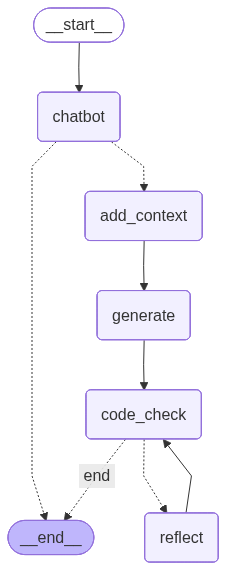

In [32]:
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [33]:
question = "titanic.csv 데이터의 전처리를 부탁합니다!"

In [34]:
solution = graph.invoke({"messages": [("user", question)], "iterations": 0, "error": ""})

##### HI #####
첫번째 LLM 호출 결과:  content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 66, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_560af6e559', 'id': 'chatcmpl-CVp0LVRydY4VzE3xoGRjFCKltUvfG', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--a8033da9-8b35-4d49-b258-8c2de4c4aca9-0' tool_calls=[{'name': 'describe_data', 'args': {'csv': 'titanic.csv'}, 'id': 'call_KFZOZZUWUqQ4NvN8xwbovDhk', 'type': 'tool_call'}] usage_metadata={'input_tokens': 66, 'output_tokens': 17, 'total_tokens': 83, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
##### ADD CONTEX

<string>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<string>:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform 

In [35]:
print(solution["generation"].prefix,"\n")
print(solution["generation"].imports,"\n")
print(solution["generation"].code)

Preprocessing the Titanic dataset to handle missing values, convert categorical columns, drop unnecessary columns, and prepare for modeling. 

import pandas as pd
import numpy as np 

# Load the dataset
df = pd.read_csv('titanic.csv')

# Handle missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

# Convert categorical columns using one-hot encoding
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Drop unnecessary columns
df.drop(columns=['Name', 'Ticket', 'PassengerId'], inplace=True)

# Separate features and target variable
X = df.drop('Survived', axis=1)
y = df['Survived']
